# Exercises for Section 3.1 Estimates and estimators

This notebook contains the solutions to the exercises
from [Section 3.1 Estimates and estimators]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Simplified int and float __repr__
import numpy as np
np.set_printoptions(legacy='1.25')

In [3]:
# Pandas display options
pd.set_option("display.precision", 2)

In [4]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

### Estimator functions defined in Section 3.1

In [5]:
def mean(sample):
    return sum(sample) / len(sample)

def var(sample):
    xbar = mean(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

def std(sample):
    s2 = var(sample)
    return np.sqrt(s2)

def dmeans(xsample, ysample):
    dhat = mean(xsample) - mean(ysample)
    return dhat

## Exercises 1


### Exercise 3.1

Compute the sample mean from Batch 01 and Batch 04 of the kombucha dataset `datasets/kombucha.csv` .

In [6]:
# @studentprompt
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]

# compute the mean of Batch 1


In [7]:
# @solution
kombucha = pd.read_csv("datasets/kombucha.csv")

# compute the mean of Batch 1
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
mean(ksample01)

999.10375

In [8]:
# @studentprompt
ksample04 = kombucha[kombucha["batch"]==4]["volume"]

# compute the mean of Batch 4


In [9]:
# @solution
ksample04 = kombucha[kombucha["batch"]==4]["volume"]

# compute the mean of Batch 4
mean(ksample04)

1003.8335

### Exercise 3.2

Compute the sample variance from Batch 02 and Batch 08 of the kombucha dataset `datasets/kombucha.csv`.

In [10]:
# @studentprompt
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample02 = ...  # select Batch 02 here...

# compute its variance 


In [11]:
# @solution
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample02 = kombucha[kombucha["batch"]==2]["volume"]
var(ksample02)

124.31760105263139

In [12]:
# @studentprompt
ksample08 = ... # select Batch 08 here... 

# compute its variance


In [13]:
# @solution
ksample08 = kombucha[kombucha["batch"]==8]["volume"]
var(ksample08)

169.9979220512824

### Exercise 3.3

Compute the difference between the means of the sleep `score`s 
for the doctors working in `rur`al and `urb`an locations
in the doctors dataset `datasets/doctors.csv`.

Hint: Use the code `doctors[doctors["loc"]=="rur"]` to select
the subset of the doctors working in a `rural` location.

In [14]:
# @studentprompt
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = ... # select doctors from "urb" location here

# compute difference between scores


In [15]:
# @solution
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# observed difference between scores
dmeans(scoresR,scoresU)

6.992885375494076

## Exercises 2


### Exercise 3.4

Generate $N=10000$ observations from the sampling distribution of the estimator `std` for samples of size $n=20$ from the population `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Plot a histogram.

In [16]:
# @studentprompt
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

# generate the sampling distribution of the standard deviation
from ministats import gen_sampling_dist
kstds20 = ...

In [17]:
# @studentprompt
# plot histogram of the sampling distribution `kstds20`
...

Ellipsis

In [18]:
# @solution
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

# generate the sampling distribution of the standard deviation
from ministats import gen_sampling_dist
kstds20 = gen_sampling_dist(rvK, estfunc=std, n=20, N=10000)
kstds20[0:5]

[7.844538691824835,
 8.668006568848247,
 12.676598792640402,
 12.759680292732662,
 9.522517609980206]

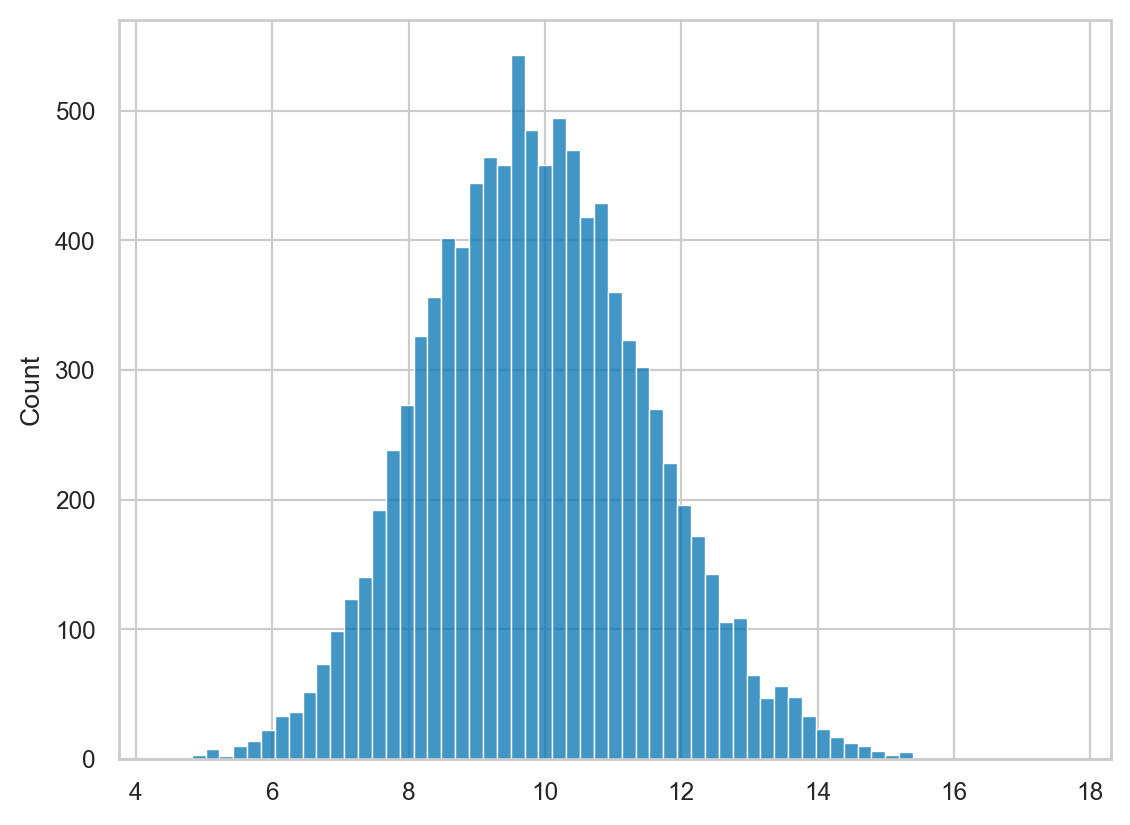

In [19]:
# @solution
# plot histogram of the sampling distribution
sns.histplot(kstds20);

### Exercise 3.5

Generate the sampling distributions of the estimator `mean` for samples of size $n=10$ , $n=30$ , and $n=100$ from the population `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Plot a histogram for each distribution.
Plot also the probability density function of the normal approximations
predicted by the central limit theorem for each case.

In [20]:
# @studentprompt
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

# simulations of Xbar for different sample sizes:
xbars10 = ... 
xbars30 = ... 
xbars100 = ... 

In [21]:
# @solution
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

# simulations of Xbar for different sample sizes:
xbars10 = gen_sampling_dist(rvK, estfunc=mean, n=10)
xbars30 = gen_sampling_dist(rvK, estfunc=mean, n=30)
xbars100 = gen_sampling_dist(rvK, estfunc=mean, n=100)

In [22]:
# @studentprompt
# CASE n = 10

# Plot the histogram obtained from simulation
...

# Find the CLT approximation
seKbar10 = ...
rvKbarCLT10 = norm(..., ...)

# Plot the pdf of the CLT approximation
from ministats import plot_pdf
...

Ellipsis

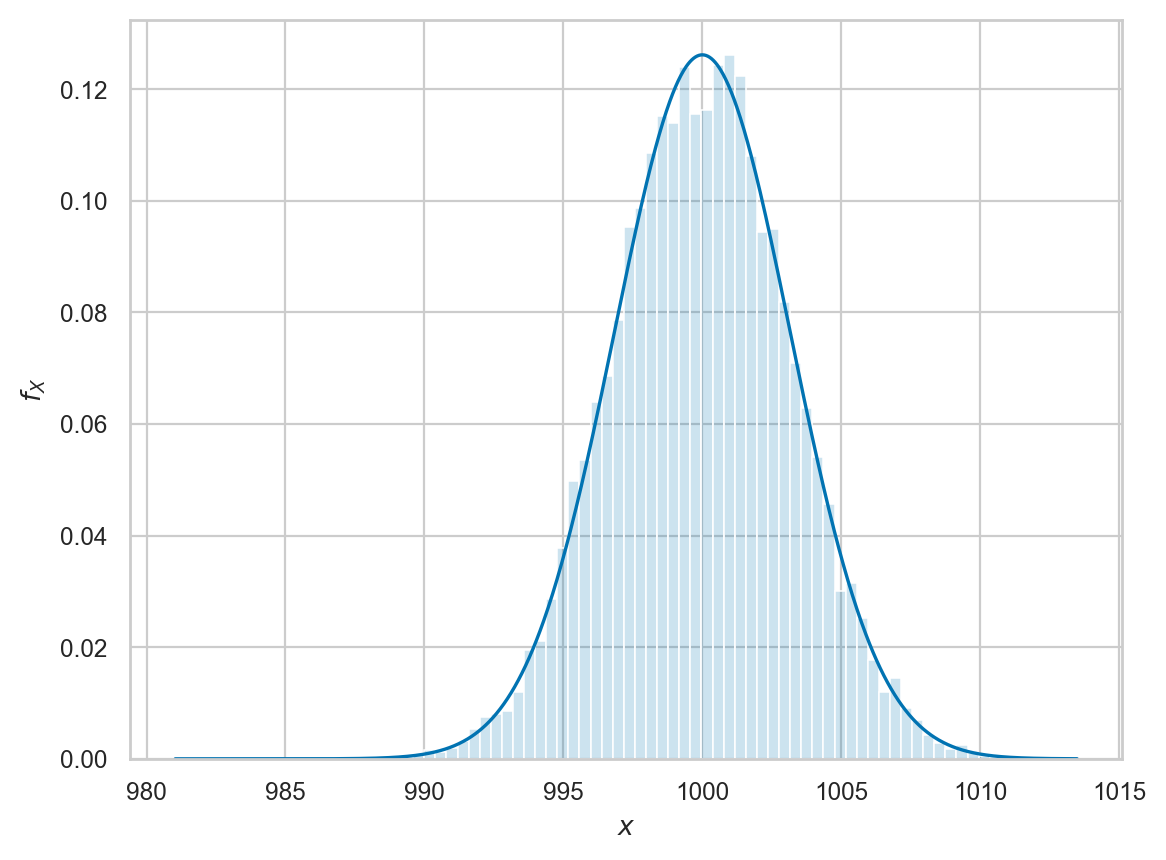

In [23]:
# @solution
# CASE n = 10

# Plot the histogram obtained from simulation
ax = sns.histplot(xbars10, stat="density", alpha=0.2)

# Find the CLT approximation
seKbar10 = sigmaK / np.sqrt(10)
rvKbarCLT10 = norm(muK, seKbar10)

# Plot the pdf of the CLT approximation
from ministats import plot_pdf
plot_pdf(rvKbarCLT10, ax=ax);

In [24]:
# @studentprompt
# CASE n = 30



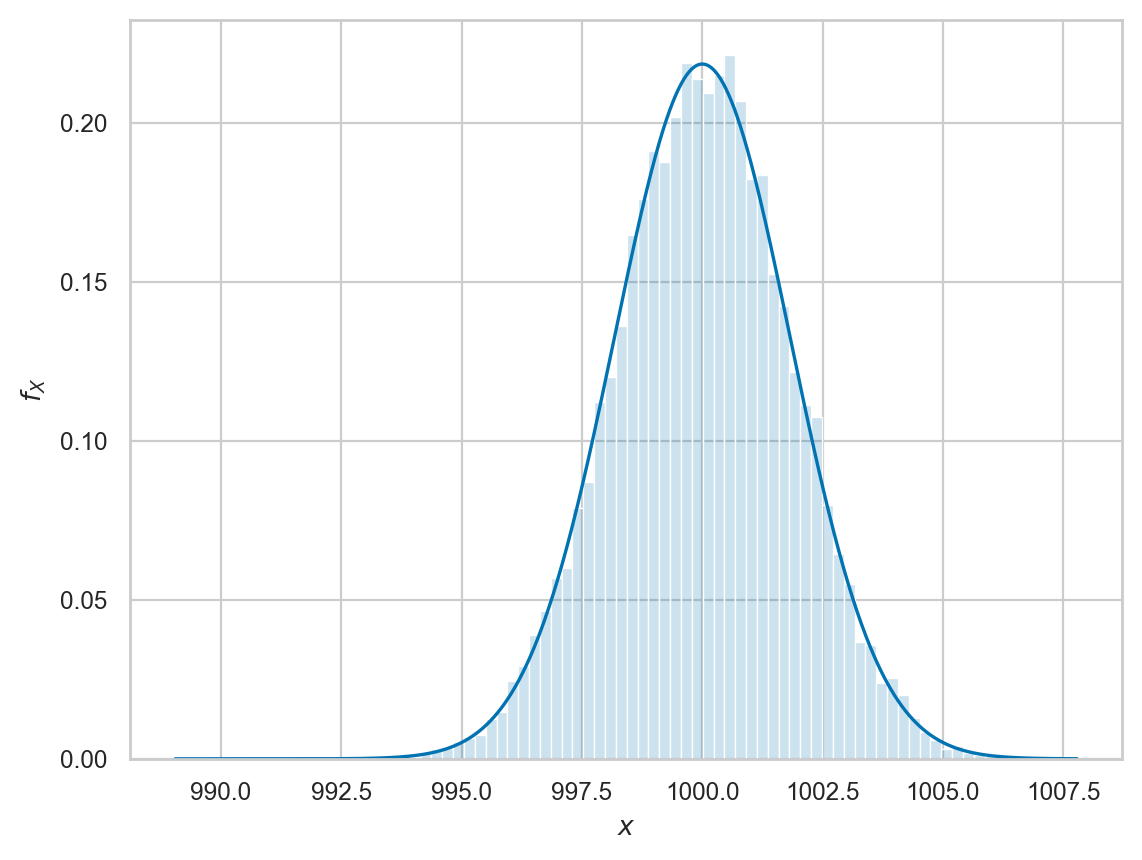

In [25]:
# @solution
# CASE n = 30

# Plot the histogram obtained from simulation
ax = sns.histplot(xbars30, stat="density", alpha=0.2)

# Find the CLT approximation
seKbar30 = sigmaK / np.sqrt(30)
rvKbarCLT30 = norm(muK, seKbar30)

# Plot the pdf of the CLT approximation
plot_pdf(rvKbarCLT30, ax=ax);

In [26]:
# @studentprompt
# CASE n = 100



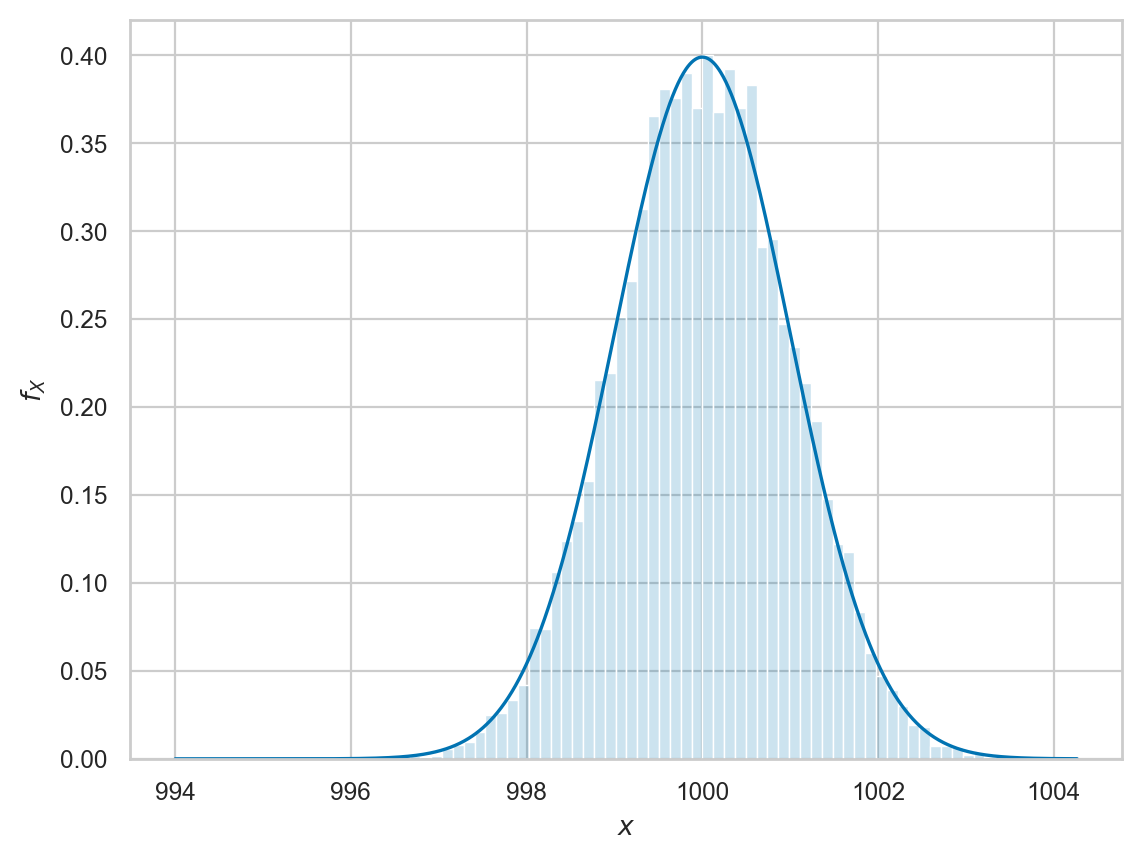

In [27]:
# @solution
# CASE n = 100

# Plot the histogram obtained from simulation
ax = sns.histplot(xbars100, stat="density", alpha=0.2)

# Find the CLT approximation
seKbar100 = sigmaK / np.sqrt(100)
rvKbarCLT100 = norm(muK, seKbar100)

# Plot the pdf of the CLT approximation
plot_pdf(rvKbarCLT100, ax=ax);

### Exercise 3.6

Generate sampling distribution of the mean for samples of size $n=30$ from the standard uniform model `rvU`  $= U \sim \mathcal{U}(0,1)$ .
Plot a histogram.
Compare your result with Figure~ \ref{fig:sampling_dist_of_Ubar} on page \pageref{fig:sampling_dist_of_Ubar} .
Plot the prediction of the central limit theorem on the same axis.

In [28]:
# @studentprompt
from scipy.stats import uniform
rvU = uniform(0,1)

# the mean and standard deviation of the population are
muU = rvU.mean()
sigmaU = rvU.std()
muU, sigmaU

(0.5, 0.28867513459481287)

In [29]:
# @solution
from scipy.stats import uniform
rvU = uniform(0,1)

# the mean and standard deviation of the population are
muU = rvU.mean()
sigmaU = rvU.std()
muU, sigmaU

(0.5, 0.28867513459481287)

In [30]:
# @studentprompt
# simulations of Ubar for samples of size 30
ubars30 = ...

# Plot the histogram obtained from simulation
...  # hint: ax = sns.histplot(ubars30, stat="density")

# Find the CLT approximation
...

# Plot the pdf of the CLT approximation
from ministats import plot_pdf
... 

Ellipsis

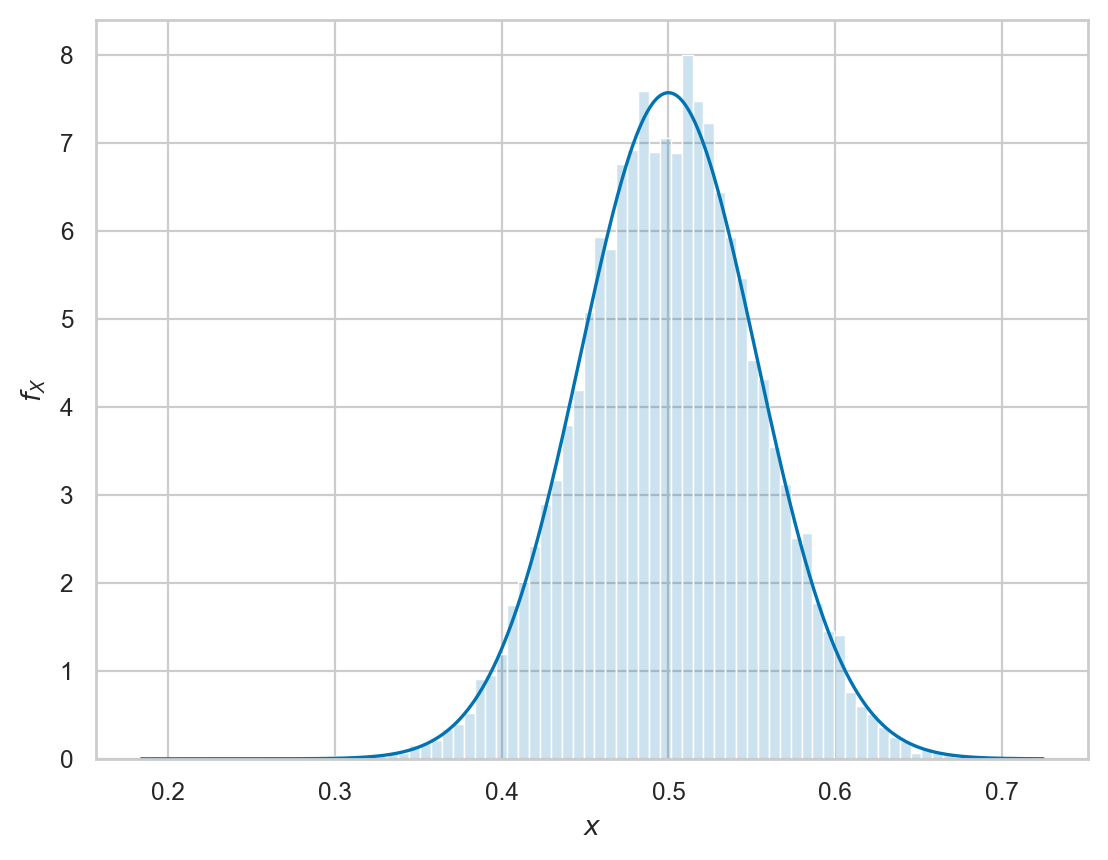

In [31]:
# @solution
# simulations of Ubar for samples of size 30
ubars30 = gen_sampling_dist(rvU, estfunc=mean, n=30)

# Plot the histogram obtained from simulation
ax = sns.histplot(ubars30, stat="density", alpha=0.2)

# Find the CLT approximation
seUbar30 = sigmaU / np.sqrt(30)
rvUbarCLT30 = norm(muU, seUbar30)

# Plot the pdf of the CLT approximation
plot_pdf(rvUbarCLT30, ax=ax);

## Exercises 3


### Exercise 3.7

Use bootstrap estimation to obtain an approximation to the sampling distribution of the mean
from the sample of apple weights in the dataset `datasets/apples.csv` .
Based on your result,
what can you say about the unknown population mean $\mu_A$?
What is the standard error of your estimate?
State your answer as $\overline{\mathbf{a}} \pm \stderrhat{\overline{\mathbf{a}}}$ and interpret in words.

In [32]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
apples.head(3)

,weight
0,205.0
1,182.0
2,192.0


In [33]:
# @studentprompt
from ministats import gen_boot_dist

abars_boot = ... 

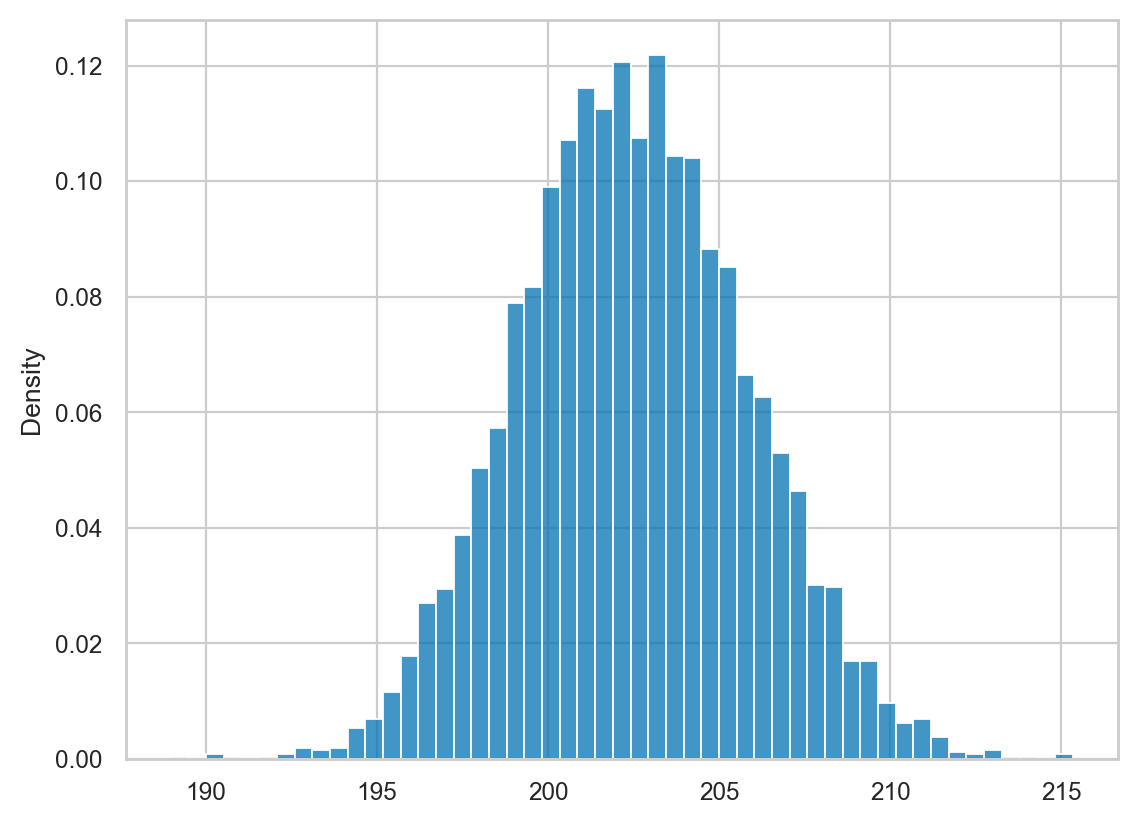

In [34]:
# @solution
from ministats import gen_boot_dist

abars_boot = gen_boot_dist(asample, estfunc=mean)

sns.histplot(abars_boot, stat="density");

In [35]:
# @studentprompt
# compute mean and standard deviation of abars_boot


In [36]:
# @solution
np.mean(abars_boot), np.std(abars_boot)

(202.48469333333333, 3.3369794617554627)

<!-- @solution -->
Based on the data in `asample`,
the unknown mean of the apples population is roughly $\mu_A \approx \overline{\mathbf{a}} = 202.5$,
and the standard deviation of this estimate about the mean 
is given by the estimate standard error $\stderrhat{\overline{\mathbf{a}}} = 3.36$.

### Exercise 3.8

Compute bootstrap distribution for the sample mean from Batch 04 of the kombucha dataset,
and plot a histogram.
Do you think Batch 04 is a regular batch or an irregular batch of production?

In [37]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample04 = kombucha[kombucha["batch"]==4]["volume"]
mean(ksample04)

1003.8335

<!-- @solution -->
The mean of computed from the sample 04 is $\overline{\mathbf{x}}_{04} = 1003.8335$,
which is higher than expected from a regular batch ($\mu_K = 1000$).

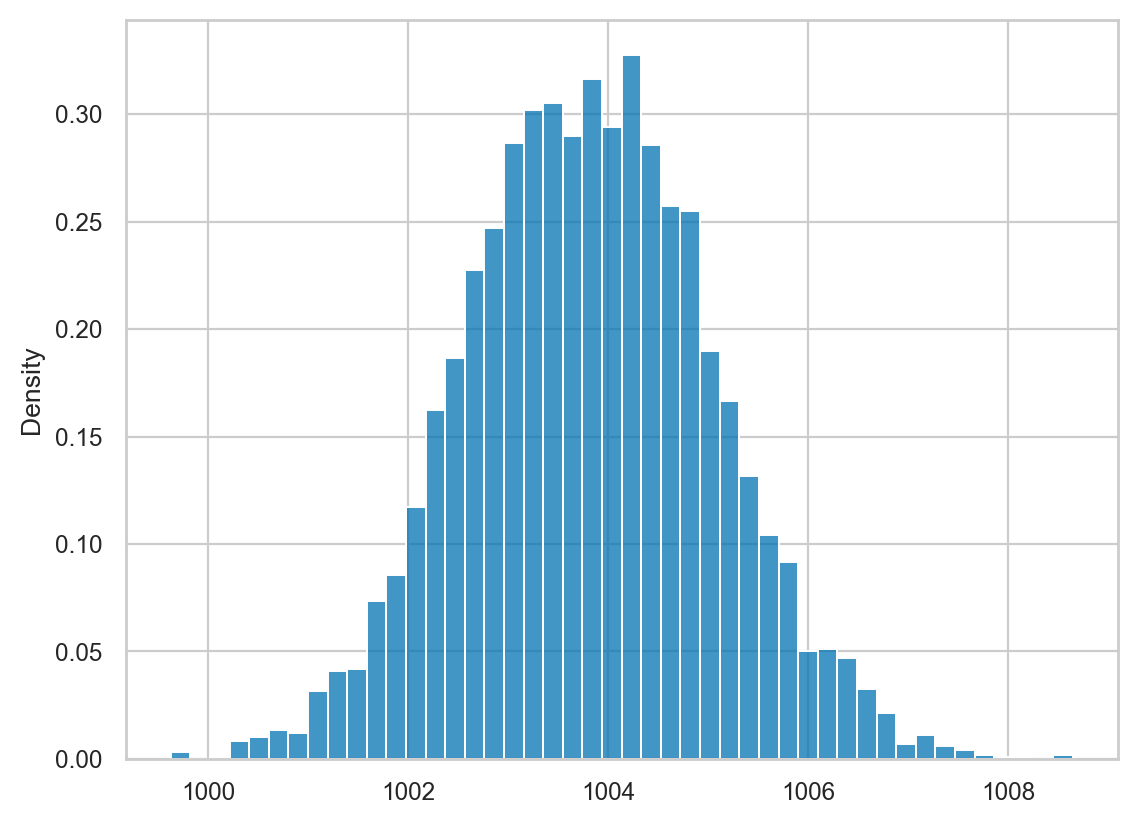

In [38]:
# @solution
kbars04_boot = gen_boot_dist(ksample04, estfunc=mean)
sns.histplot(kbars04_boot, stat="density");

<!-- @solution -->
Even when we take into account of the possible variability
in the estimate $\overline{\mathbf{x}}_{04}$
we see that the we're still very far from the expected mean $\mu_K = 1000$.

This means the Batch 04 is likely not regular batch:
the volume in this batch is higher than expected for regular batches $\mu_K = 1000$.

## Exercises 4

### E3.9

Describe your uncertainty about the unknown population mean $\mu_A$ based on sample of apple weights from the dataset `datasets/apples.csv`:  
**a)** find an analytical formula in terms Student's $t$ -distribution,  
**b)** use bootstrap estimation,  
**c)** compare your answers from part a) and b) graphically.

In [39]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
apples.head(3)

,weight
0,205.0
1,182.0
2,192.0


In [40]:
# @studentprompt
# a) Find the CLT approximation
from scipy.stats import t as tdist

n = asample.count()
df = ...
loc = ...
scale = ...
rvTAbar = tdist(df, loc=loc, scale=scale)

# Plot the pdf of the CLT approximation
...

Ellipsis

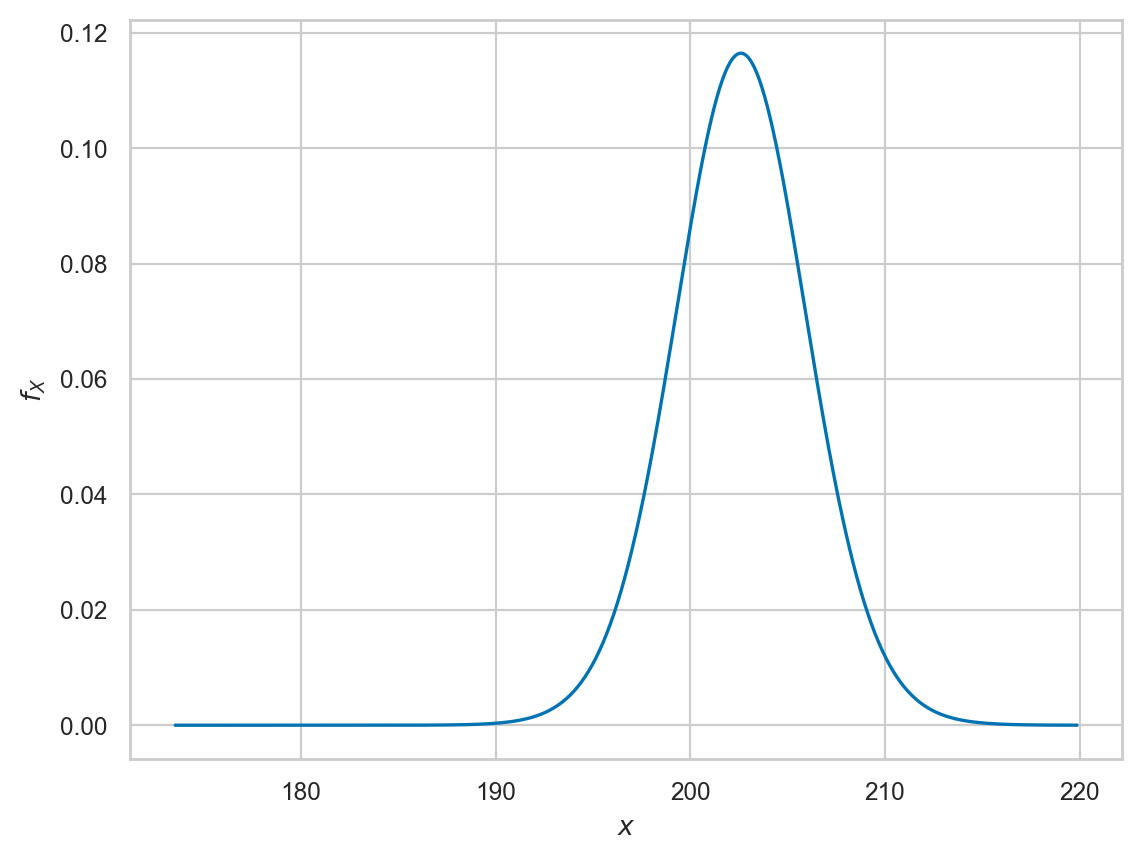

In [41]:
# @solution
# a) Find the CLT approximation
from scipy.stats import t as tdist

n = asample.count()
df = n-1
loc = mean(asample)
scale = std(asample) / np.sqrt(30)
rvTAbar = tdist(df, loc=loc, scale=scale)

# Plot the pdf of the CLT approximation
ax = plot_pdf(rvTAbar)

In [42]:
# @studentprompt
# b) obtain a bootstrap approximation
abars_boot = ...


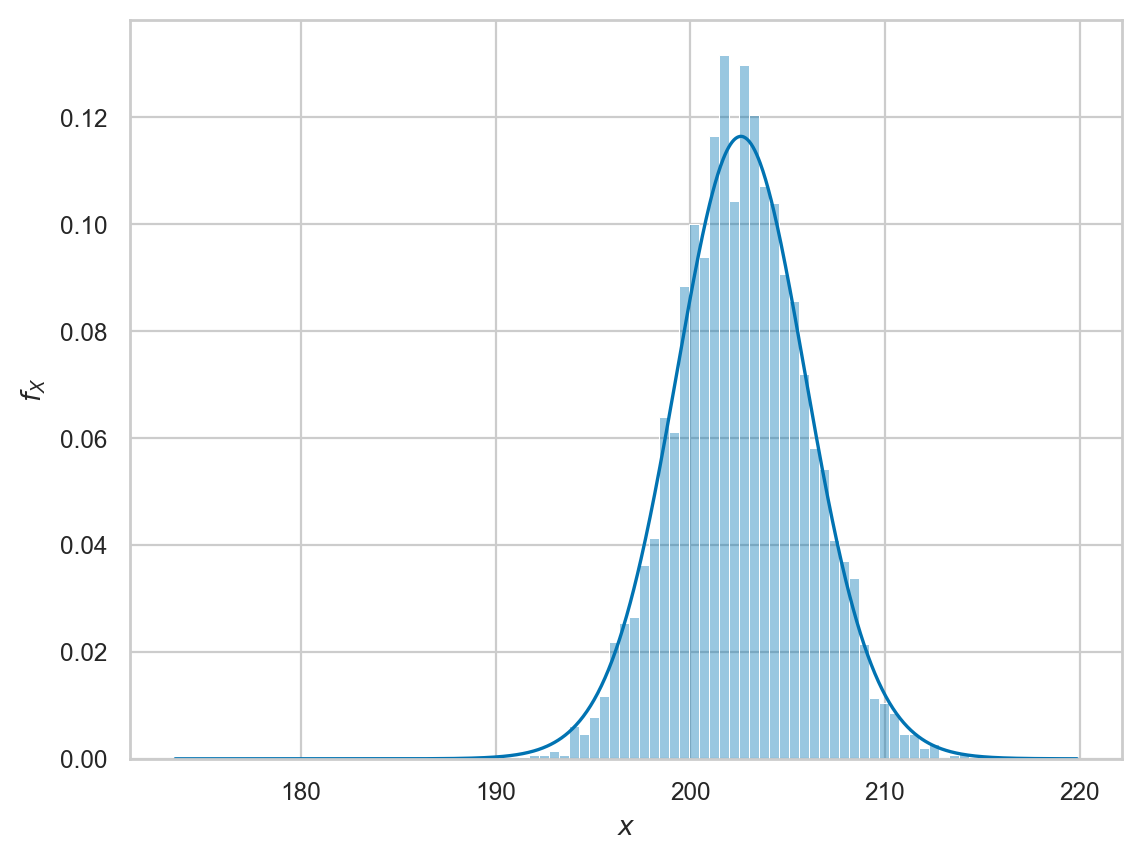

In [43]:
# @solution
# b) obtain a bootstrap approximation
abars_boot = gen_boot_dist(asample, estfunc=mean)
sns.histplot(abars_boot, stat="density", ax=ax, alpha=0.4)
ax.figure

## Exercises 5


### Exercise 3.10

Under regular operations,
the kombucha volume is described by the model `rvK`  $= K \sim \mathcal{N}(1000,10)$ .  
**a)** Plot the probability density function for the sampling distribution of the variance for samples of size $n=40$ from the population $K$ .  
**b)** Compute the sample variance of Batch 08 from the kombucha dataset.  
**c)** Compare the observed value in b) to the sampling distribution in a).
Does it look like this is a regular batch or irregular batch?

In [44]:
# @studentprompt
# a) Find the sampling distribution of the sample variance
from scipy.stats import chi2

n = ...
df = ...
scale = ...
rvS2 = chi2(df, loc=0, scale=scale)

# Plot the pdf of the CLT approximation
...

Ellipsis

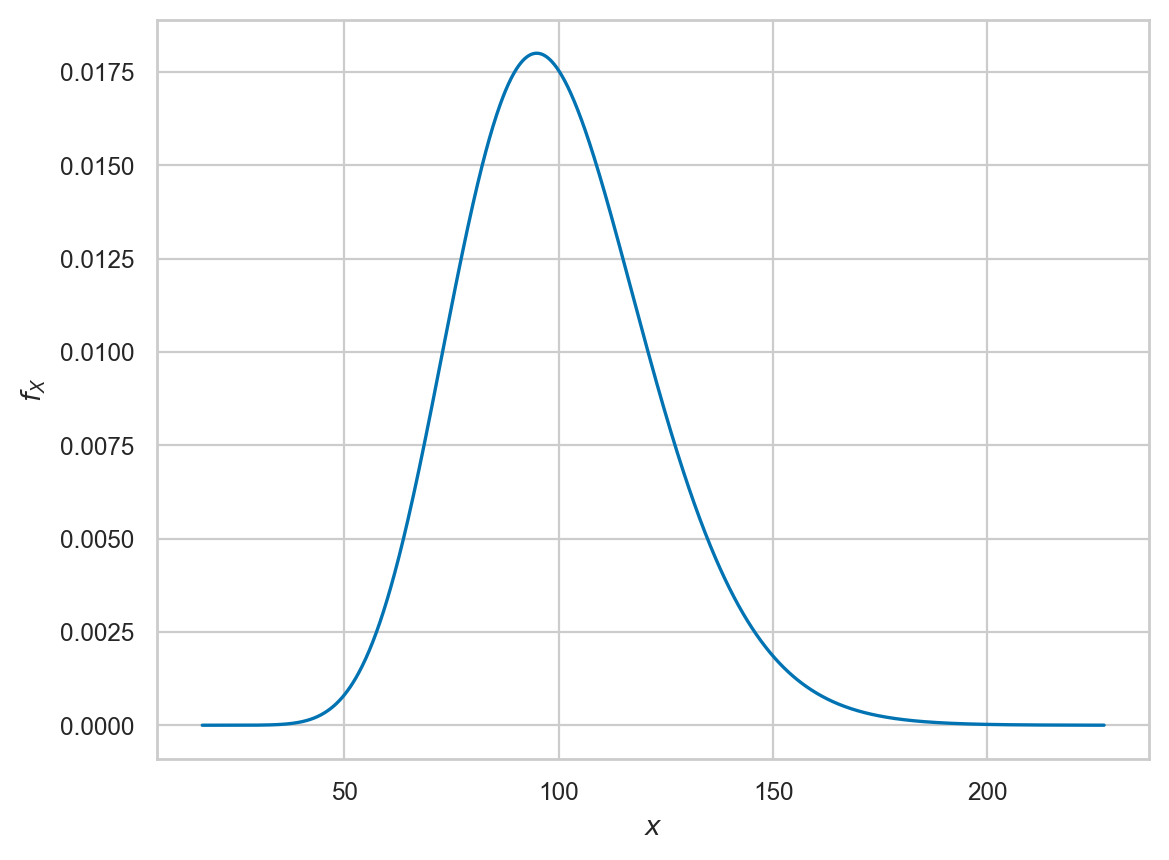

In [45]:
# @solution
# a) Find the sampling distribution of the sample variance
from scipy.stats import chi2

n = 40
df = n - 1
scale = sigmaK**2 / (n-1)
rvS2 = chi2(df, loc=0, scale=scale)

# Plot the pdf of the CLT approximation
plot_pdf(rvS2);

In [46]:
# @studentprompt
# b) the sample variance of Batch 04 is
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = ... # select Batch 08 here


In [47]:
# @solution
# b) the sample variance of Batch 04 is
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]
var(ksample08)

169.9979220512824

<!-- @solution -->
c) The observed value $s_{\mathbf{k}_{08}} = 167$ is very unlikely to occur
under the expected sampling distribution for the sample variance
for regular samples.
This suggests that Batch 08 is an irregular batch with abnormally high variance.
Better check the machine.

### Exercise 3.11

Compute the bootstrap approximation for sampling distribution of the variance
from Batch 08 of the kombucha dataset.
Plot a histogram.

In [48]:
# @studentprompt
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = ... # select Batch 08 here ...

kvars08_boot = ...


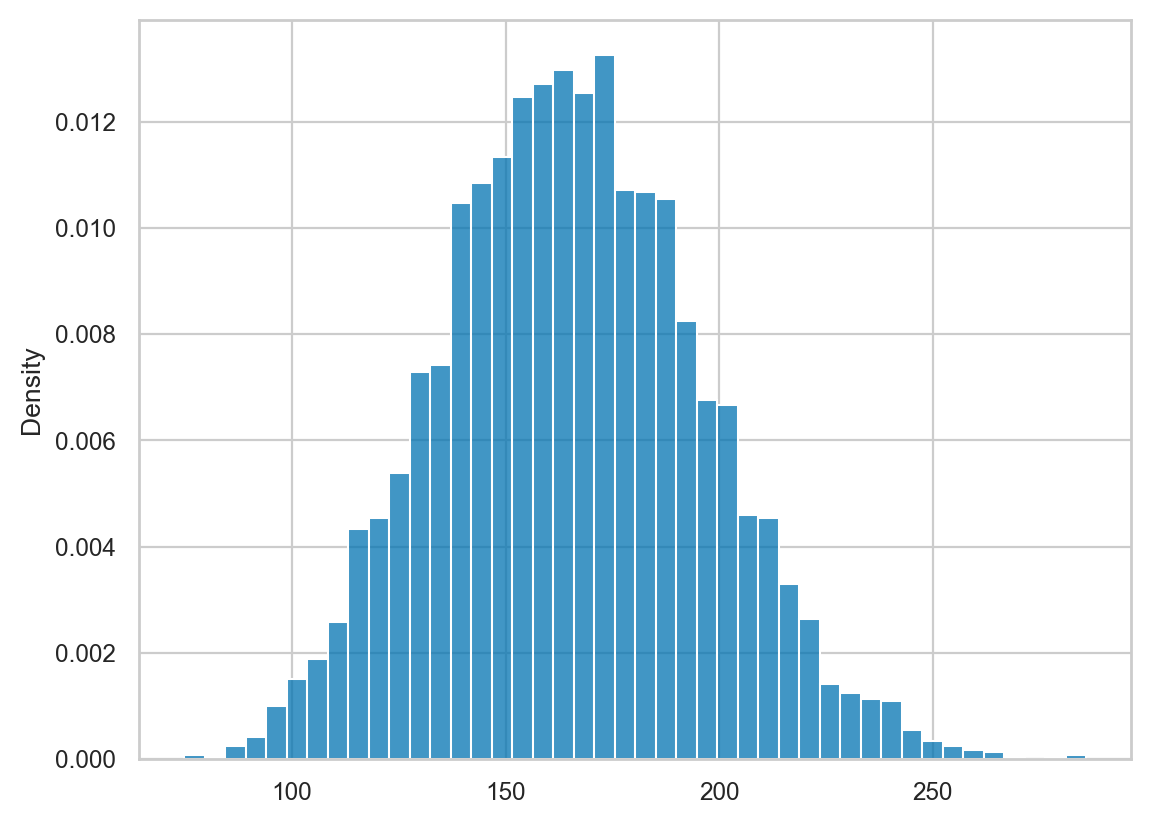

In [49]:
# @solution
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

kvars08_boot = gen_boot_dist(ksample08, estfunc=var)
sns.histplot(kvars08_boot, stat="density");

<!-- @solution -->
The bootstrap estimates we observe are very far from the 
expected standard deviation for regular batches,
which is $\sigma_K^2 = 100$,
which tells us Batch 08 might be irregular (abnormally high variance).

## Exercises 6


### Exercise 3.12

Describe the uncertainty about the difference between means `dmeans(scoresR,scoresU)`,
where `scoresR` and `scoresU` are sleep scores of the rural and urban doctors
from the doctors dataset `datasets/doctors.csv`.  
**a)** Find an analytical formula in terms Student's $t$ -distribution.  
**b)** Use bootstrap estimation.  
**c)** Compare your answers from part a) and b) graphically.

In [50]:
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# observed value
dscores = dmeans(scoresR, scoresU)
dscores

6.992885375494076

In [51]:
# @studentprompt
# a) analytical approximation

# obtain the sample sizes and stds of the two groups
...

# compute standard error of the difference between group means
...

# calculate the degrees of freedom
from ministats import calcdf
...

# probability model based on Student's t-distribution
from scipy.stats import t as tdist
...

Ellipsis

In [52]:
# @solution
# a) analytical approximation

# obtain the sample sizes and stds of the two groups
nR = scoresR.count()
stdR = scoresR.std()
nU = scoresU.count()
stdU = scoresU.std()

# standard error of the difference between group means
seDhatscores = np.sqrt(stdU**2/nU + stdR**2/nR)
print("Estimated sample standard error", seDhatscores)

# calculate the degrees of freedom
from ministats import calcdf
df = calcdf(stdU, nU, stdR, nR)

# probability model based on Student's t-distribution
from scipy.stats import t as tdist
rvDscores = tdist(df, loc=dscores, scale=seDhatscores)

Estimated sample standard error 3.5671565854251948


In [53]:
# @studentprompt
# b) bootstrap estimate
# compute bootstrap estimates for mean in each group
meanR_boot = ... 
meanU_boot = ...

# compute the difference between means of bootstrap samples
dmeans_boot = ...


In [54]:
# @solution
# b) bootstrap estimate
# compute bootstrap estimates for mean in each group
meanR_boot = gen_boot_dist(scoresR, estfunc=mean)
meanU_boot = gen_boot_dist(scoresU, estfunc=mean)

# compute the difference between means of bootstrap samples
dmeans_boot = np.subtract(meanR_boot, meanU_boot)
# show first of the 5 boostrap estimate sin the list of N=10000
# dmeans_boot[0:5]

In [55]:
# @studentprompt
# c) plot the answers form a) and b)

# pdf of the analytical approximation 
...

# histogtam of the bootstrap approximation
...

Ellipsis

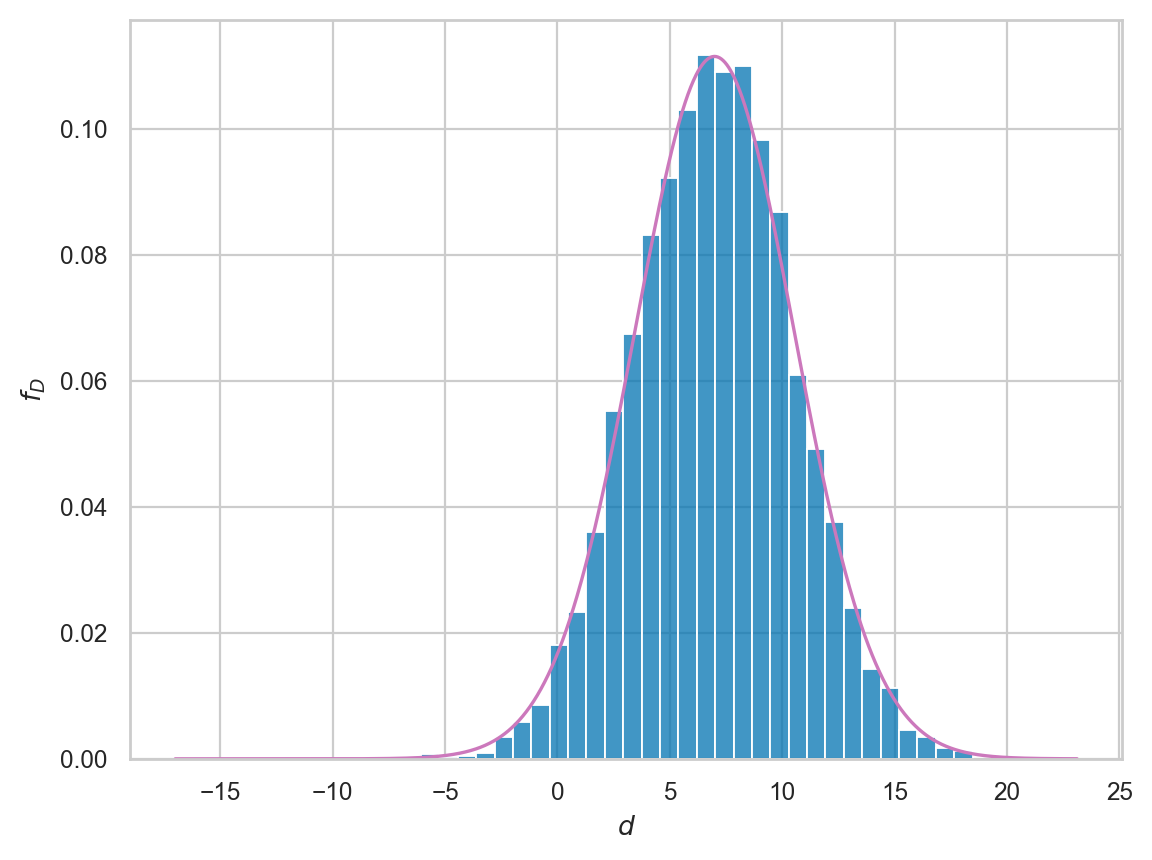

In [56]:
# @solution
# c) plot the answers form a) and b)

# pdf of the analytical approximation 
ax = plot_pdf(rvDscores, rv_name="D", color="C4")

# histogtam of the bootstrap approximation
sns.histplot(dmeans_boot, ax=ax, stat="density", bins=30);

## Exercises 7


### Exercise 3.13

Generate the sampling distribution of the median for samples of size $n=30$ from the population `rvK` $= K \sim \mathcal{N}(1000,10)$ .

In [57]:
# @studentprompt
from scipy.stats import norm
rvK = norm(1000, 10)

# compute the sampling distribution of the median
# for samples of size n=30 from rvK
kmedians30 = ...


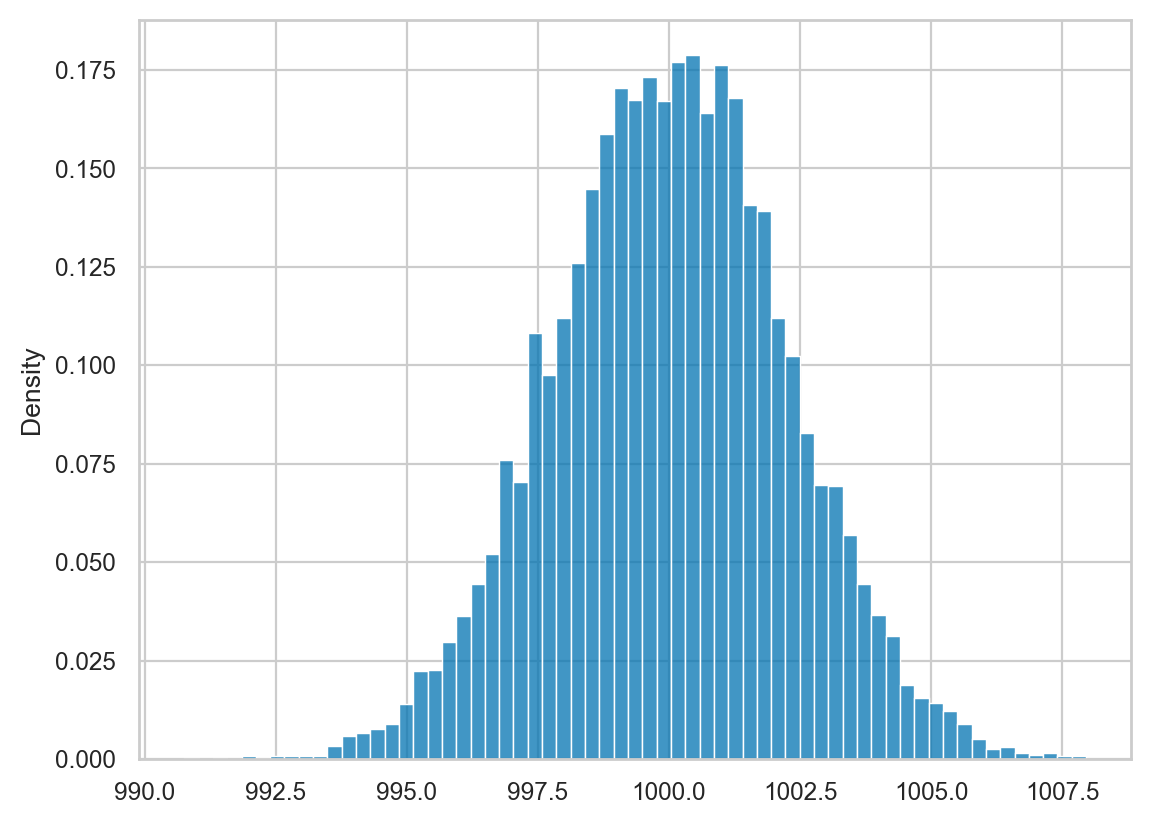

In [58]:
# @solution
from scipy.stats import norm
rvK = norm(1000, 10)

# compute the sampling distribution of the median
# for samples of size n=30 from rvK
kmedians30 = gen_sampling_dist(rvK, estfunc=np.median, n=30)
sns.histplot(kmedians30, stat="density");

In [59]:
# @studentprompt
# compute se of the sampling distribution of the median
...

Ellipsis

In [60]:
# @solution
# compute se of the sampling distribution of the median 
np.std(kmedians30)

2.2229175780488957

### Exercise 3.14

Generate the sampling distribution of `P90` , the 90th percentile estimator,
from samples of size $n=30$ from `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Calculate the standard error $\stderr{\tt{P90}}$ of the estimator.

In [61]:
from scipy.stats import norm
rvK = norm(1000, 10)

In [62]:
# @studentprompt
# 90th percentile estimator function
def p90(sample):
    ...

# simulations of p90 from samples of size n=30
kp90s30 = gen_sampling_dist(rvK, estfunc=p90, n=30)

# histogram
...

Ellipsis

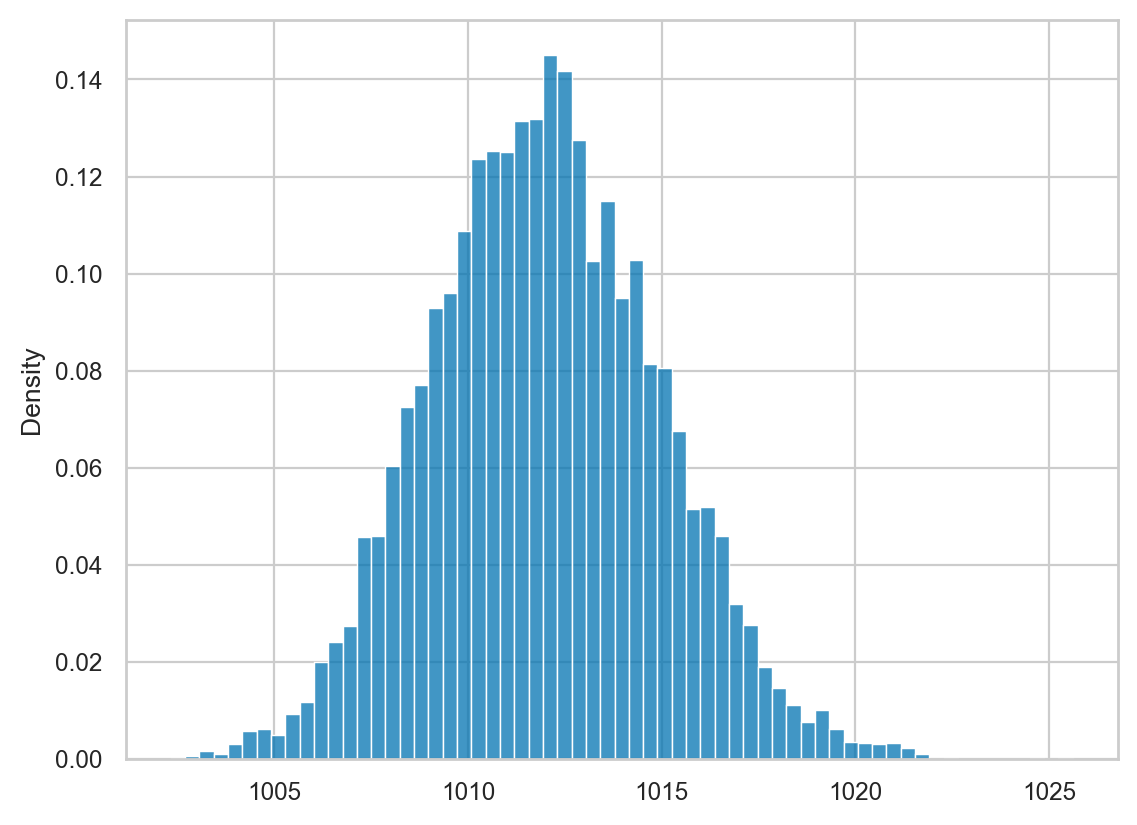

In [63]:
# @solution
# 90th percentile estimator function
def p90(sample):
    return np.percentile(sample, 90)

# simulations of p90 from samples of size n=30
kp90s30 = gen_sampling_dist(rvK, estfunc=p90, n=30)
sns.histplot(kp90s30, stat="density");

In [64]:
# @studentprompt
# compute se of the kp90s30 sampling distribution
...

Ellipsis

In [65]:
# @solution
# compute se of the kp90s30 sampling distribution
np.std(kp90s30)  # == sehat_p90

2.9343956028292304

### Exercise 3.16

Use the function `scipy.stats.boostrap` to compute the bootstrap distribution
of the variance from the sample `ksample02`.

In [66]:
# @studentprompt
from scipy.stats import bootstrap

kombucha = pd.read_csv("datasets/kombucha.csv")
ksample02 = ...  # select Batch 02 here...

# call the function bootstrap
...

# plot histogram
...

Ellipsis

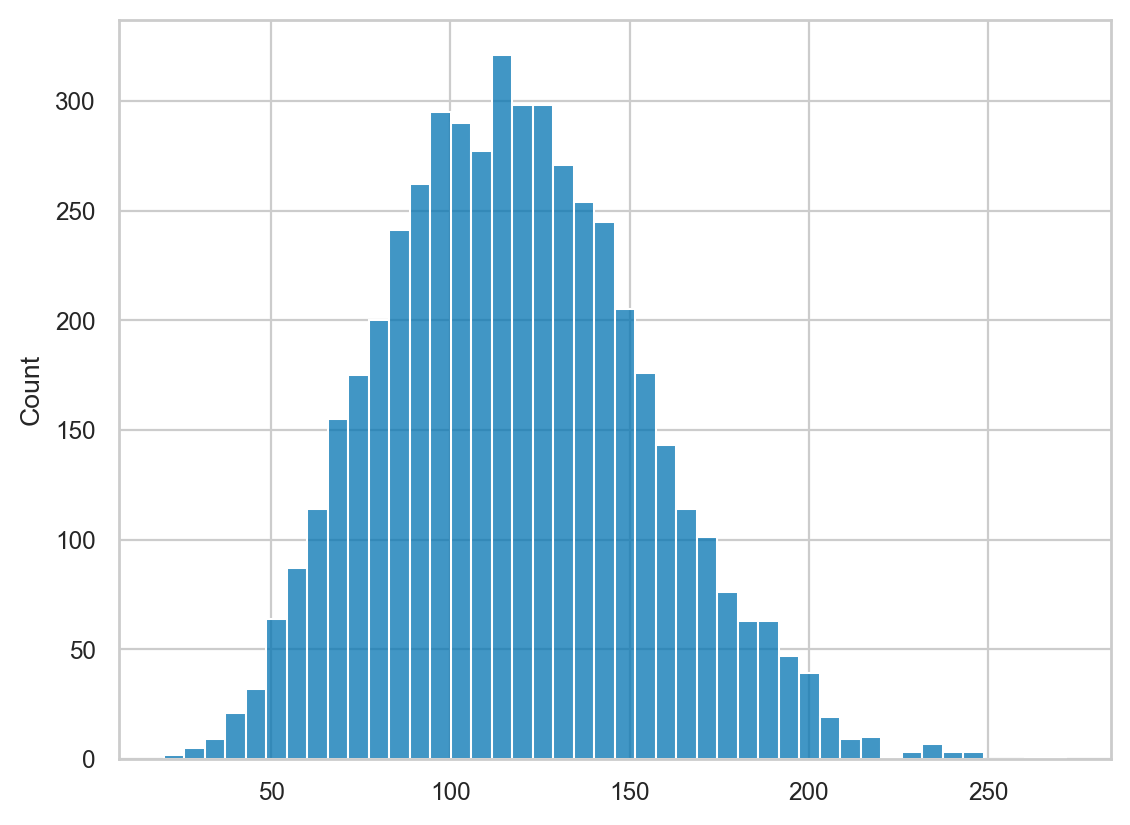

In [67]:
# @solution
from scipy.stats import bootstrap

kombucha = pd.read_csv("datasets/kombucha.csv")
ksample02 = kombucha[kombucha["batch"]==2]["volume"]

# call the function bootstrap
np.random.seed(42)
res = bootstrap((ksample02,), statistic=var,
                n_resamples=5000, vectorized=False)

# plot histogram
sns.histplot(res.bootstrap_distribution);